## **IPF for fertility model, July 2025**
### To compute IPF solution for births and population for age, ethnicity and parity; data to come from ONS and *NewEthPop*

- Existing fertility model - implemented in Minos - takes ONS data *NewEthPop* data, expands to higher parity values using geometric series, then matches mean fertility rate per cell (i.e. each $(a, e, p)$ combination) to that in *NewEthPop*
- Not ideal because some data not very good or missing entirely, most importantly population by ethnicity, which means final fertility rate may not capture ethnicity dependence correctly
- Aim is to replace with better model that accounts for ethnicity, i.e. to compute fertility rate table as function of age, ethnicity and parity, i.e. $f(a, e, p)$
- For such a 3D table constructed using IPF, ideal constraints are three 2D cross-tabulations for each combination of variables; data sources in table below
- Methodology does **not** require any manual setting to reference values and instead preserves relationships between $(a, e, p)$ through the constraints and seed data given to IPF
- Important to note that constraints data are not available for every year that Minos will run for (i.e. 2020-2035 or so)
- However, used nearest-year methodology to get constraints for nearest available year; result is that some or most *relationships between variables* are represented for all years thus produced

 Dataset ID | Variables ($xyz$)$^{1}$ | Data source | File name(s)$^{2}$ |
| --- | --- | --- | --- |
| *Population ($P$)* |
| 1 | $xy \;(ae)$ | *NewEthPop* | ```Population2020_LEEDS2.csv```$^{3}$ |
| 2 | $yz \;(ep)$ | *NewEthPop* and ONS$^{4}$ | ```Population2020_LEEDS2.csv```$^{3}$ (for $e$) and <br> ```finalfertilityratesbyparity1934to2022.xlsx``` (for $p$) |
| 3 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |
| *Births ($b$)* |
| 4 | $xy \;(ae)$ | *NewEthPop*$^{5}$ | ```Fertility2020_LEEDS1_2.csv```$^{6}$ (for $f$) and <br> ```Population2020_LEEDS2.csv```$^{3}$ (for $P$) |
| 5 | $yz \;(ep)$ | ONS | ```20182022livebirthssexparity.xlsx```$^{7}$ |
| 6 | $xz \;(ap)$ | ONS | ```finalfertilityratesbyparity1934to2022.xlsx``` |

$^{1}$ Variables $x$ = age ($a$), $y$ = ethnicity ($e$) and $z$ = parity ($p$); also $f$ = fertility rate

$^{2}$ If multiple years available, data for 2020 given as example

$^{3}$ Via ```OutputData/Population``` folder

$^{4}$ Dataset not available directly; must compute 2D IPF solution, $P(e, p)$, using 1D constraints, $P(e)$ and $P(p)$

$^{5}$ Births by age and ethnicity not given directly, so necessary to calculate $b(a, e) = f(a, e) \cdot P(a, e)$

$^{6}$ Via ```InputData/Fertility``` folder

$^{7}$ Data given as total for 2018-2022, i.e. five years; must divide by five

## Basic testing of IPF algorithm

### 1. Some basic validation of IPF output (GFR, as easily calculated from results)

In [ ]:
from minos.fertility_ipf import *


# # Compare competing constraint sets, i.e. ONS vs. NewEthPop
# xy_p, yz_p, xz_p, xy_b, yz_b, xz_b = get_constraints_data(year)

# print(xy_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=1))

# print(xz_b_corr.sum(axis=0))
# print(yz_b_corr.sum(axis=0))

# print(xy_b_corr.sum(axis=1))
# print(xz_b_corr.sum(axis=1))

# print(xy_p_corr.sum(axis=0))
# print(yz_p_corr.sum(axis=1))

# print(xz_p_corr.sum(axis=0))
# print(yz_p_corr.sum(axis=0))

# print(xy_p_corr.sum(axis=1))
# print(xz_p_corr.sum(axis=1))


# Testing get_ipf_solutions function
y = 2020
births_3d, pop_3d = get_ipf_solutions(year=y)

# Sum over parity to create 2D version, i.e. (a, e) only
births_2d = births_3d.groupby(level=['age', 'eth_group']).sum()
pop_2d = pop_3d.groupby(level=['age', 'eth_group']).sum()

# Get GFR for validation
gfr_3d = get_simple_gfr(births_3d, pop_3d)
gfr_2d = get_simple_gfr(births_2d, pop_2d)

# Compare results - should be identical
print('### Comparing 3D and 2D GFR values (births per 1,000 women aged 15-44) ###')
print("GFR(a, e, p) = {0:.6g}".format(gfr_3d))
print("GFR(a, e)    = {0:.6g}".format(gfr_2d))

### 2. Quantify effect of correcting 0/1 values in terms of births and population

In [6]:
# Get fertility rate tables
f_3d = create_fertility_table(births_3d.copy(), pop_3d.copy())
f_2d = create_fertility_table(births_2d.copy(), pop_2d.copy())

# See whether truncating/correcting fertility results affect GFR
get_correction_effects(births_3d, pop_3d)
get_correction_effects(births_2d, pop_2d)

### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 48
Unity cells in result: 219
Proportion of population with zero fertility rate (i.e. f = 0): 6.02e-05%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0.004172%
Proportion of births with zero fertility rate (i.e. f = 0): 4.565e-11%
Proportion of births with truncated fertility rate (i.e. f > 1 before correction): 0.1013%
### Calculating zero and unity cells in fertility rate table ###
Zero cells in result: 0
Unity cells in result: 0
Proportion of population with zero fertility rate (i.e. f = 0): 0%
Proportion of population with truncated fertility rate (i.e. f > 1 before correction): 0%
Proportion of births with zero fertility rate (i.e. f = 0): 0%
Proportion of births with truncated fertility rate (i.e. f > 1 before correction): 0%


(population    0.0
 dtype: float64,
 population    0.0
 dtype: float64,
 births    0.0
 dtype: float64,
 births    0.0
 dtype: float64)

## Applying fertility rate table to microsim input population

### 1. Basic validation - comparing fertility rates using 2D and 3D rate tables to reference values

In [7]:
# Get 1% synthpop and tidy up (uses Minos functionality later so must be in that format)
sp20 = get_synthpop_data(pc=1)
sp20['alive'] = 'alive'
sp20['eth_group'] = sp20['ethnicity'].map(eth_map).str.lower()

# Get crosstab for tabular calculation and grouped by (a, e, p) with zeroes retained - not finished tabular method as very fiddly
# sp20ct = pd.crosstab([sp20['age'], sp20['eth_group']], sp20['nkids_ind'])
# sp20gb = sp20.groupby(VARS_3D).size().unstack(fill_value=0).stack()  # Without unstack/stack, empty cases are excluded, e.g. 16/Asian/1

### 3D FERTILITY
sp_3d = apply_fertility_model(sp20.copy(), f_3d)
print("GFR (3D) = {} per 1,000".format(futils.get_gfr(sp_3d)))

### 2D FERTILITY
sp_2d = apply_fertility_model(sp20.copy(), f_2d)
print("GFR (2D) = {} per 1,000".format(futils.get_gfr(sp_2d)))

tfr_ref = futils.get_tfr(sp20)
tfr_actual = get_tfr_projections().loc[y].values[0]
print('TFR (ref): {}\nTFR (actual): {}'.format(tfr_ref, tfr_actual))

GFR (3D) = 58.31535260573769 per 1,000
GFR (2D) = 62.06378387899338 per 1,000
TFR (ref): 1.6850560111495068
TFR (actual): 1.51


### 2. Testing fertility rate adjustment - iteratively setting actual fertility rate to reference value

In [8]:
ref_val = get_tfr_projections().loc[y].values[0]
matched = match_rate_table(sp20, births_3d, pop_3d, cats, 'tfr', ref_val)

tfr = 1.756617929088062, ref = 1.51
0.8596063919169422
tfr = 1.5320211654228038, ref = 1.51
0.9856260697176945
tfr = 1.454382886238529, ref = 1.51
1.0382410397480084
tfr = 1.6033423552547732, ref = 1.51
0.9417826423977049
tfr = 1.4569468486279336, ref = 1.51
1.0364139236939418
tfr = 1.5389976317950314, ref = 1.51
0.9811581049925272
tfr = 1.48995247729083, ref = 1.51
1.013455142371804
tfr = 1.5215693459069213, ref = 1.51
0.9923964386256576
tfr = 1.4969819264844322, ref = 1.51
1.0086962128835717
tfr = 1.4882258140211497, ref = 1.51
1.014630969153812
tfr = 1.544850067329111, ref = 1.51
0.9774411329188967
tfr = 1.4789085788394538, ref = 1.51
1.0210232205055871
tfr = 1.5377677603147084, ref = 1.51
0.9819428128022234
tfr = 1.4968465100884283, ref = 1.51
1.0087874674009125
tfr = 1.5333431353318456, ref = 1.51
0.9847763134069832
tfr = 1.4883302253805175, ref = 1.51
1.0145597893867553
tfr = 1.5462665157717128, ref = 1.51
0.9765457536577303
tfr = 1.4660997889852034, ref = 1.51
1.0299435354568758

## Visualisation of results: comparison of IPF output with reference GFR data

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

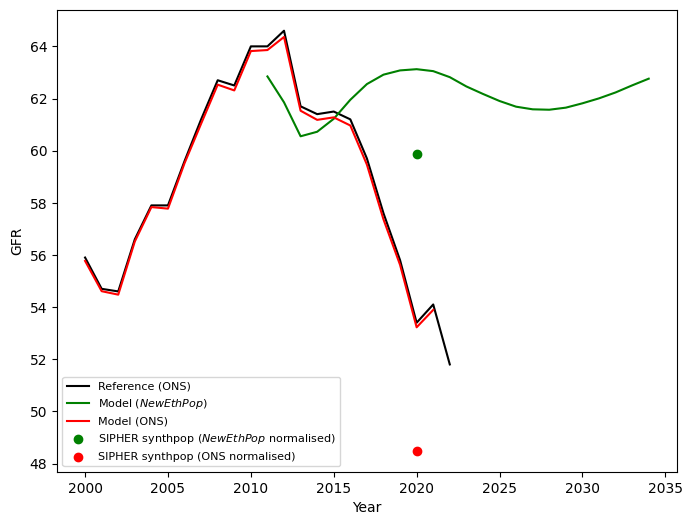

In [9]:
# Automate GFR calculations for NEP and ONS to show differences in naive GFR
nep_years = range(2011, 2035)
ons_years = range(2000, 2022)

model_data_nep = {}
for y in nep_years:
    by, py = get_ipf_solutions(year=y, normaliser='nep', recalculate=True)
    model_data_nep[y] = get_simple_gfr(by, py)
model_data_nep = pd.Series(model_data_nep)

model_data_ons = {}
for y in ons_years:
    by, py = get_ipf_solutions(year=y, normaliser='ons', recalculate=True)
    model_data_ons[y] = get_simple_gfr(by, py)
model_data_ons = pd.Series(model_data_ons)

# Add some points for the SIPHER synthpop (2020) for comparison
y = 2020

result_nep = get_ipf_solutions(year=y, normaliser='nep', recalculate=True)
rt_nep = create_fertility_table(*result_nep)
pop_nep = apply_fertility_model(sp20, rt_nep)
synthpop_result_nep = {y: futils.get_gfr(pop_nep)}

result_ons = get_ipf_solutions(year=y, normaliser='ons', recalculate=True)
rt_ons = create_fertility_table(*result_ons)
pop_ons = apply_fertility_model(sp20, rt_ons)
synthpop_result_ons = {y: futils.get_gfr(pop_ons)}

# Get TFR reference data
ref_data = futils.get_fertility_reference_data()
ref_data = ref_data.loc[ref_data.index >= 2000]['gfr_ref']

# Create plot
fig = plt.figure(figsize=(8, 6))
ax1 = fig.add_subplot(111)

ax1.plot(ref_data, label='Reference (ONS)', c='black')
# ax1.plot(ref_data, label='Reference (HFD)', c='gray')
ax1.plot(model_data_nep, label='Model ($\it{NewEthPop}$)', c='green')
ax1.plot(model_data_ons, label='Model (ONS)', c='red')
ax1.scatter(*zip(*synthpop_result_nep.items()), label='SIPHER synthpop ($\it{NewEthPop}$ normalised)', c='green')
ax1.scatter(*zip(*synthpop_result_ons.items()), label='SIPHER synthpop (ONS normalised)', c='red')

plt.xlabel('Year')
plt.ylabel('GFR')
plt.legend(loc=3, prop={'size': 8})
plt.show()